#Module 2 : Feature Extraction and Representation Learning

L'idée derrière ce module est d'obtenir une représentation des données qui soit à la fois robuste et discriminante, afin de mieux détecter les comportements anormaux (comme des attaques zero‑day) par la suite. Voici pourquoi chaque étape a été réalisée :


**Vérification des caractéristiques existantes :**


*Pourquoi ?*
Pour s'assurer que les données prétraitées sont de bonne qualité, qu'elles sont correctement distribuées et qu'il n'existe pas de corrélations indésirables ou de problèmes majeurs.

*But :*

Comprendre les propriétés des données afin de prendre de bonnes décisions lors de la conception des modèles. C'est un prérequis pour tout pipeline de machine learning.

**Apprentissage auto‑supervisé contrastif (SimCLR) :**


*Pourquoi ?*
Les données ne sont pas toujours annotées, surtout dans des environnements de sécurité (où il n'est pas toujours évident d'avoir des labels pour chaque type de trafic).

L'approche contrastive permet d'apprendre à partir de données non étiquetées en créant des paires positives (deux vues différentes de la même donnée) et en forçant le modèle à rapprocher leurs représentations.

*But :*
Apprendre des représentations (embeddings) qui capturent les caractéristiques essentielles des données malgré les variations (par exemple, bruit, décalages temporels).
Ces embeddings, une fois sauvegardés, serviront de base pour la détection d'anomalies dans les modules suivants.

**Visualisation et Analyse (avec t-SNE) :**


*Pourquoi ?*

Visualiser les embeddings permet de vérifier visuellement que le modèle a bien appris à regrouper les données similaires et à séparer celles qui sont différentes.

*But :*

Comprendre la structure de l'espace de représentation.

Valider que les caractéristiques extraites sont cohérentes et discriminantes, ce qui est essentiel pour identifier des anomalies (par exemple, des attaques) par la suite.

*:Summary ;*
* Explore and validate existing features:





- Train a contrastive learning model (SimCLR):


Define simple augmentations.


Build an encoder and a projector.


Train using the NT-Xent loss on the profiling (normal) data.


Save the encoder after training.


- Visualize the learned embeddings:

Use t-SNE to inspect the quality of the embeddings.


- Save the embeddings for both profiling and attack data:

These embeddings will be used in the anomaly detection step in later modules.

#Step 2.1: Explore and Validate Existing Features

Charger les données prétraitées du Module 1 :



Explorer les caractéristiques :


Vérifie la distribution de certaines colonnes importantes (par exemple, Header-Length, Rate, etc.).


Analyse la corrélation entre les variables pour identifier d’éventuelles redondances ou caractéristiques discriminantes.

Mounted at /content/drive
Profiling Data:
   Header_Length  Protocol Type  Time_To_Live      Rate  fin_flag_number  \
0       0.780711      -0.520156     -0.352225  0.161819        -0.182138   
1       0.780711      -0.520156     -0.352225  0.046431        -0.182138   
2       0.780711      -0.520156     -0.352225  0.848682        -0.182138   
3       0.780711      -0.520156     -0.352225  0.167966        -0.182138   
4       0.780711      -0.520156     -0.352225 -0.478872        -0.182138   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0        -0.183033        -0.106416        -0.896082         0.706737   
1        -0.183033        -0.106416        -1.272999         0.706737   
2        -0.183033        -0.106416        -0.896082         0.706737   
3        -0.183033        -0.106416        -0.896082         0.706737   
4        -0.183033        -0.106416        -0.142249         0.706737   

   ece_flag_number  ...       LLC   Tot sum       Min       Ma

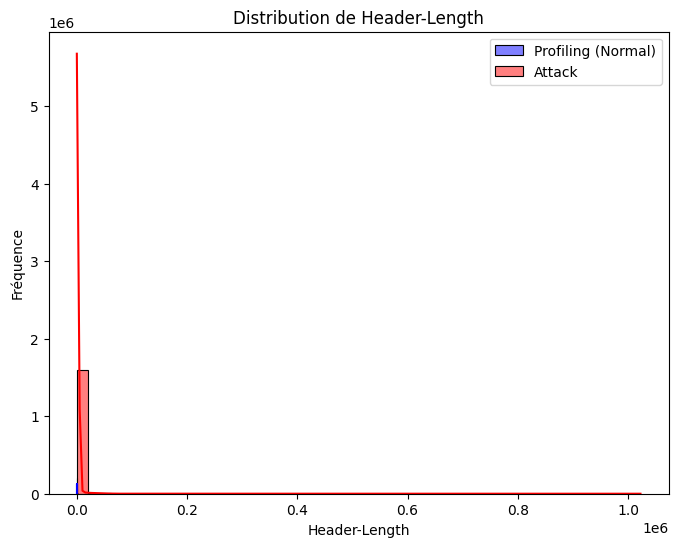

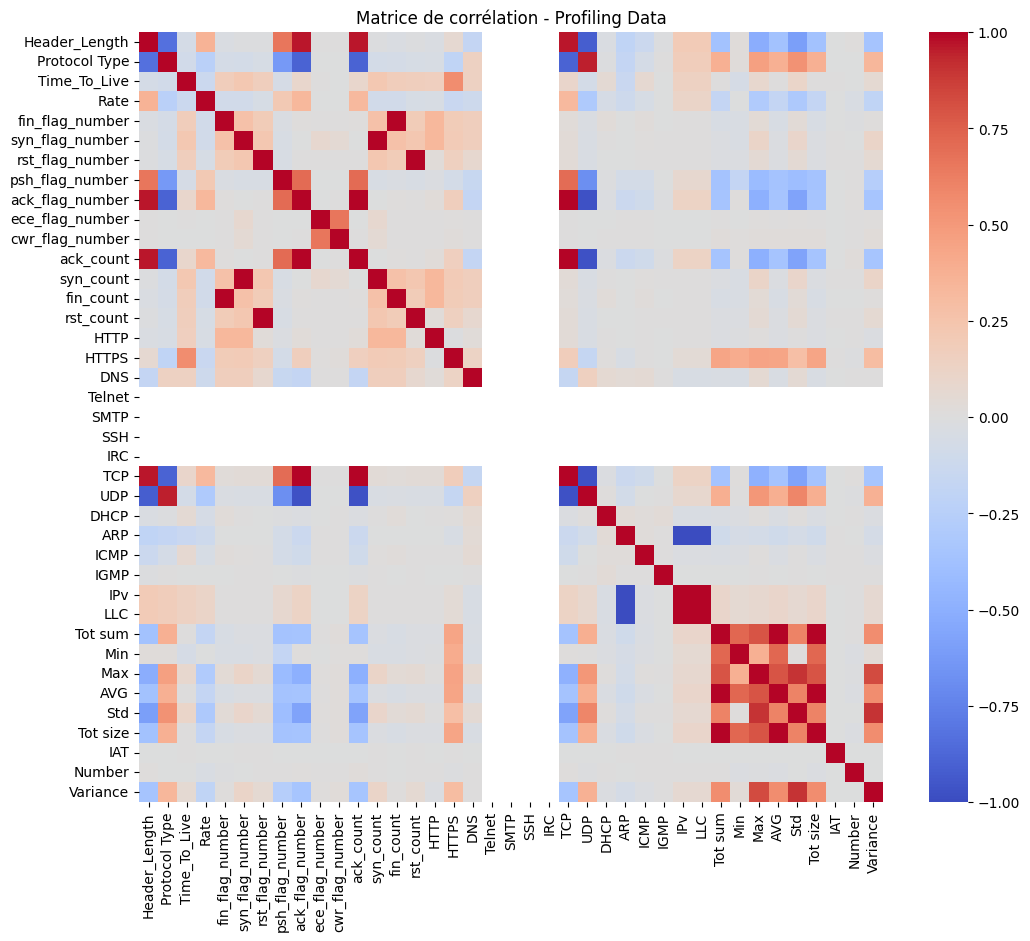

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# Charger les données normalisées du Module 1
df_profiling = pd.read_csv("/content/drive/MyDrive/zeroday_detection/data/df_mqtt_profiling_scaled.csv")
df_attack = pd.read_csv("/content/drive/MyDrive/zeroday_detection/data/df_mqtt_attack_scaled.csv")

# Afficher un aperçu
print("Profiling Data:")
print(df_profiling.head())
print("Attack Data:")
print(df_attack.head())

# Afficher les statistiques descriptives
print(df_profiling.describe())

# Visualiser la distribution d'une caractéristique clé, par exemple "Header_Length"
plt.figure(figsize=(8, 6))
sns.histplot(df_profiling['Header_Length'], bins=50, kde=True, color='blue', label="Profiling (Normal)")
sns.histplot(df_attack['Header_Length'], bins=50, kde=True, color='red', label="Attack")
plt.xlabel("Header-Length")
plt.ylabel("Fréquence")
plt.title("Distribution de Header-Length")
plt.legend()
plt.show()

# Visualiser la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(df_profiling.corr(), annot=False, cmap="coolwarm")
plt.title("Matrice de corrélation - Profiling Data")
plt.show()


1. Identifier et gérer les Outliers

In [ ]:
import numpy as np

# Suppose df_profiling et df_attack sont tes DataFrames normalisés

# Choisir une ou plusieurs colonnes où tu suspectes des outliers, par ex. "Header_Length"
col = "Header_Length"

# Définir un seuil pour considérer une valeur comme extrême (e.g., 3 ou 4 fois l'écart-type)
threshold_std = 4
mean_val = df_profiling[col].mean()
std_val = df_profiling[col].std()

# Repérer les outliers dans le Profiling
outliers_profiling = df_profiling[ (df_profiling[col] > mean_val + threshold_std * std_val) |
                                   (df_profiling[col] < mean_val - threshold_std * std_val) ]
print(f"Outliers dans Profiling ({col}): {len(outliers_profiling)}")

# De même pour Attack
mean_val_attack = df_attack[col].mean()
std_val_attack = df_attack[col].std()

outliers_attack = df_attack[ (df_attack[col] > mean_val_attack + threshold_std * std_val_attack) |
(df_attack[col] < mean_val_attack - threshold_std * std_val_attack) ]
print(f"Outliers dans Attack ({col}): {len(outliers_attack)}")

# Inspecter quelques lignes pour voir si c'est cohérent
print("Exemples d'outliers (profiling):")
print(outliers_profiling.head())


Outliers dans Profiling (Header_Length): 0
Outliers dans Attack (Header_Length): 7757
Exemples d'outliers (profiling):
Empty DataFrame
Columns: [Header_Length, Protocol Type, Time_To_Live, Rate, fin_flag_number, syn_flag_number, rst_flag_number, psh_flag_number, ack_flag_number, ece_flag_number, cwr_flag_number, ack_count, syn_count, fin_count, rst_count, HTTP, HTTPS, DNS, Telnet, SMTP, SSH, IRC, TCP, UDP, DHCP, ARP, ICMP, IGMP, IPv, LLC, Tot sum, Min, Max, AVG, Std, Tot size, IAT, Number, Variance]
Index: []

[0 rows x 39 columns]


Pour la caractéristique "Header_Length", les données de profiling semblent correctes et homogènes. Les outliers présents dans les données d’attaque reflètent probablement la nature anormale des attaques, ce qui est positif pour la détection. on peut donc les conserver dans ton pipeline d’anomalie, car ils seront essentiels pour que le modèle identifie les comportements déviants.

2. Déterminer un seuil de corrélation

In [ ]:
threshold_corr = 0.95
corr_matrix = df_profiling.corr()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > threshold_corr)]

print("Features fortement corrélées (>", threshold_corr, "):", high_corr_features)


Features fortement corrélées (> 0.95 ): ['ack_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'TCP', 'UDP', 'IPv', 'LLC', 'AVG', 'Tot size']


# Step 2.2: Learn Robust Representations with Contrastive Learning (SimCLR)

Using an auto‑supervised contrastive approach can help learn embeddings that better separate normal and anomalous traffic.

**A. Define Data Augmentation Function**

Since you are working with tabular data (or features from network traffic), you can use simple augmentations such as adding random noise.

In [ ]:
import tensorflow as tf

def augmentation_fn(x):
    # Add Gaussian noise as a simple augmentation
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.1)
        return x + noise


**B. Build the Encoder and Projector Networks**

The encoder learns to map the input features to a latent space, and the projector maps these embeddings into a space where contrastive loss is applied.

In [ ]:
from tensorflow.keras import layers, models

def build_encoder(input_dim, embedding_dim=64):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(embedding_dim, activation='relu')(x)
    model = models.Model(inputs, x)
    return model

def build_projector(embedding_dim=64, projection_dim=32):
    inputs = layers.Input(shape=(embedding_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    outputs = layers.Dense(projection_dim)(x)  # No activation; projections can be raw
    model = models.Model(inputs, outputs)
    return model

# Parameters
input_dim = df_profiling.shape[1]  # number of features
embedding_dim = 64
projection_dim = 32

encoder = build_encoder(input_dim, embedding_dim)
projector = build_projector(embedding_dim, projection_dim)


**C. Define the Forward Pass for SimCLR**

This function creates two augmented views of the same input and produces their embeddings and projections.

In [ ]:
def simclr_forward(x):
      # Create two different augmented versions of the input
      x1 = augmentation_fn(x)
      x2 = augmentation_fn(x)

      # Pass through encoder to obtain embeddings
      h1 = encoder(x1)
      h2 = encoder(x2)

      # Project embeddings into contrastive space
      z1 = projector(h1)
      z2 = projector(h2)
      return z1, z2


**D. Define the NT-Xent Loss (Contrastive Loss)**

This loss pushes together representations from two views of the same sample and pulls apart different samples.



In [ ]:
def nt_xent_loss(z1, z2, temperature=0.5):
      # Normalize projections
       z1 = tf.math.l2_normalize(z1, axis=1)
       z2 = tf.math.l2_normalize(z2, axis=1)
       z = tf.concat([z1, z2], axis=0)
       similarity_matrix = tf.matmul(z, z, transpose_b=True)

       # Mask out self-similarity by setting diagonal to -infinity
       batch_size = tf.shape(z1)[0]
       mask = tf.linalg.diag(tf.ones(2 * batch_size))
       logits = similarity_matrix / temperature
       logits = logits - 1e9 * mask  # effectively masking diagonal entries

       # Create labels: for each example in the concatenated batch,
       # the positive pair is at index i+batch_size (for i < batch_size) and vice versa.
       labels = tf.concat([tf.range(batch_size, 2 * batch_size), tf.range(0, batch_size)], axis=0)
       loss = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
       loss = tf.reduce_mean(loss)
       return loss


**E. Train the SimCLR Model**

Train the encoder and projector using the contrastive loss on your profiling (normal) data.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
batch_size = 128
num_epochs = 1

# Convert profiling data to a TensorFlow Dataset
data = df_profiling.to_numpy().astype('float32')
dataset = tf.data.Dataset.from_tensor_slices(data).shuffle(10000).batch(batch_size)

for epoch in range(num_epochs):
    total_loss = 0
    num_batches = 0
    for batch in dataset:
        with tf.GradientTape() as tape:
            z1, z2 = simclr_forward(batch)
            loss = nt_xent_loss(z1, z2)
        grads = tape.gradient(loss, encoder.trainable_variables + projector.trainable_variables)
        optimizer.apply_gradients(zip(grads, encoder.trainable_variables + projector.trainable_variables))
        total_loss += loss.numpy()
        num_batches += 1
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss/num_batches:.4f}")


Epoch 1/1 - Loss: 3.8908


remarque:  La perte stagne après quelques époques, ce qui signifie que le modèle n’apprend pas beaucoup de nouvelles informations.

In [ ]:
# Save the encoder for future use
encoder.save("/content/drive/MyDrive/zeroday_detection/code/simclr_encoder_v2.keras")
# encoder.save("/content/drive/MyDrive/zeroday_detection/simclr_encoder_v2.h5")

In [ ]:
encoder.save("/content/drive/MyDrive/zeroday_detection/simclr_encoder_v3.h5")

**Step 2.3: Visualize the Learned Embeddings**

Use t-SNE or UMAP to project the learned embeddings to 2D space and check if the representations of normal data show structure.

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


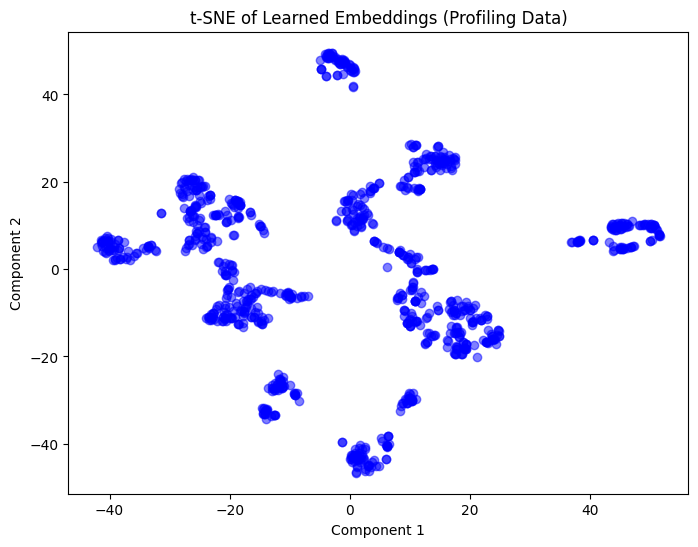

In [ ]:
from sklearn.manifold import TSNE

# Take a sample of normal data
sample_data = data[:1000]
embeddings = encoder.predict(sample_data)

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.5)
plt.title("t-SNE of Learned Embeddings (Profiling Data)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


**Step 2.4: Save the Embeddings**

In [ ]:
# For normal data
embeddings_normal = encoder.predict(data)
np.save("/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy", embeddings_normal)

# For attack data
data_attack = df_attack.to_numpy().astype('float32')
embeddings_attack = encoder.predict(data_attack)
np.save("/content/drive/MyDrive/zeroday_detection/data/embeddings_attack_v2.npy", embeddings_attack)


12187/12187 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step


PermissionError: [Errno 1] Operation not permitted: '/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy'

Step 2.5: Visualize Attack Embeddings on t-SNE

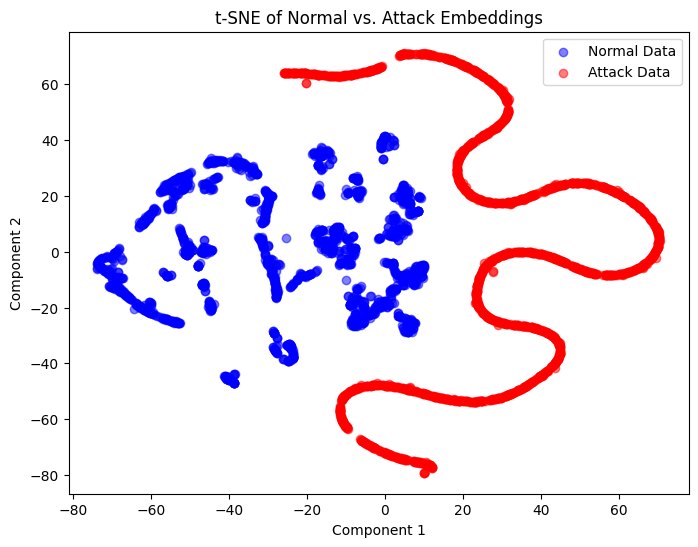

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Load saved embeddings
embeddings_normal = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy")
embeddings_attack = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_attack_v2.npy")

# Sample a subset for visualization (optional, to speed up t-SNE)
sample_size = 2000
normal_sample = embeddings_normal[:sample_size]
attack_sample = embeddings_attack[:sample_size]

# Concatenate both normal and attack embeddings
all_embeddings = np.vstack((normal_sample, attack_sample))
labels = np.array([0] * len(normal_sample) + [1] * len(attack_sample))  # 0 = Normal, 1 = Attack

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[labels == 0, 0], embeddings_2d[labels == 0, 1], c='blue', alpha=0.5, label="Normal Data")
plt.scatter(embeddings_2d[labels == 1, 0], embeddings_2d[labels == 1, 1], c='red', alpha=0.5, label="Attack Data")
plt.title("t-SNE of Normal vs. Attack Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()


Step 2.6: Compute Clustering Metrics

Silhouette Score: 0.1359


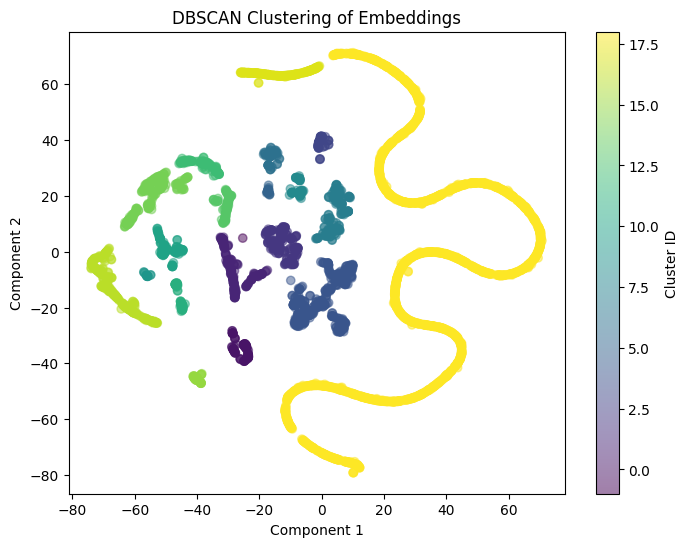

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Run DBSCAN clustering on embeddings
dbscan = DBSCAN(eps=5, min_samples=10).fit(embeddings_2d)

# Compute silhouette score
silhouette = silhouette_score(embeddings_2d, dbscan.labels_)
print(f"Silhouette Score: {silhouette:.4f}")

# Visualize clusters
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=dbscan.labels_, cmap='viridis', alpha=0.5)
plt.title("DBSCAN Clustering of Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster ID")
plt.show()


Step 2.7: Train Density-Based Anomaly Detector

In [ ]:
from sklearn.mixture import GaussianMixture

# Train GMM on normal data embeddings
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(embeddings_normal)

# Compute log-likelihood scores for attack data
attack_scores = gmm.score_samples(embeddings_attack)

# Set threshold for anomaly detection
threshold = np.percentile(attack_scores, 5)  # 5% percentile as anomaly cutoff
anomalies = attack_scores < threshold

# Print anomaly detection results
print(f"Detected {sum(anomalies)} attack samples as anomalies out of {len(attack_scores)} total.")


Detected 80603 attack samples as anomalies out of 1614182 total.


**Fix & Validate Step 2**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)  # Reduce LR
batch_size = 256  # Increase batch size
num_epochs = 100  # Train longer

# Convert profiling data to a TensorFlow Dataset
data = df_profiling.to_numpy().astype('float32')
dataset = tf.data.Dataset.from_tensor_slices(data).shuffle(10000).batch(batch_size)

for epoch in range(num_epochs):
    epoch_loss = 0

    for batch in dataset:

        with tf.GradientTape() as tape:
             z1, z2 = simclr_forward(batch)
             loss = nt_xent_loss(z1, z2)
        grads = tape.gradient(loss, encoder.trainable_variables + projector.trainable_variables)
        optimizer.apply_gradients(zip(grads, encoder.trainable_variables + projector.trainable_variables))
        epoch_loss += loss.numpy()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss/len(dataset):.4f}") # Corrected indentation

Epoch 1/100 - Loss: 4.6240
Epoch 2/100 - Loss: 4.5657
Epoch 3/100 - Loss: 4.5484
Epoch 4/100 - Loss: 4.5378
Epoch 5/100 - Loss: 4.5321
Epoch 6/100 - Loss: 4.5271
Epoch 7/100 - Loss: 4.5241
Epoch 8/100 - Loss: 4.5210
Epoch 9/100 - Loss: 4.5189
Epoch 10/100 - Loss: 4.5172
Epoch 11/100 - Loss: 4.5149
Epoch 12/100 - Loss: 4.5138
Epoch 13/100 - Loss: 4.5118
Epoch 14/100 - Loss: 4.5108
Epoch 15/100 - Loss: 4.5100
Epoch 16/100 - Loss: 4.5096
Epoch 17/100 - Loss: 4.5083
Epoch 18/100 - Loss: 4.5084
Epoch 19/100 - Loss: 4.5066
Epoch 20/100 - Loss: 4.5064
Epoch 21/100 - Loss: 4.5060
Epoch 22/100 - Loss: 4.5046
Epoch 23/100 - Loss: 4.5041
Epoch 24/100 - Loss: 4.5032
Epoch 25/100 - Loss: 4.5028
Epoch 26/100 - Loss: 4.5026


KeyboardInterrupt: 